## Feature Extraction Workshop

In this workshop, we shall perform Feature Extraction using PCA

In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

1. Please use the dataset wine.csv for the questions that follow.

In [4]:
# Load dataset
wine_df = pd.read_csv("wine.csv")
wine_df.head()

,Cultivar,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


2. Assume that our label is ‘Cultivar’ and the rest of the columns are our features.

In [74]:
# 2. Label and features
X = wine_df.drop('Cultivar', axis = 1)
y = wine_df['Cultivar']

print(f"X\n{X.head()}\n\ny\n{y.iloc[:5]}")

X
   Alcohol  Malic acid   Ash  Alcalinity of ash  Magnesium  Total phenols  \
0    14.23        1.71  2.43               15.6        127           2.80   
1    13.20        1.78  2.14               11.2        100           2.65   
2    13.16        2.36  2.67               18.6        101           2.80   
3    14.37        1.95  2.50               16.8        113           3.85   
4    13.24        2.59  2.87               21.0        118           2.80   

   Flavanoids  Nonflavanoid phenols  Proanthocyanins  Color intensity   Hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   OD280/OD315 of diluted wines  Proline  
0                

3. Visualize your data by creating distribution plots for the 4 features - Alcalinity of ash,
Flavanoids, Hue and Proline.<br>a. Use Seaborn’s histplot() function to generate the plots.<br>b. Differentiate each plot by the ‘Cultivar’ feature by setting hue=‘Cultivar’ in the
histplot() function.

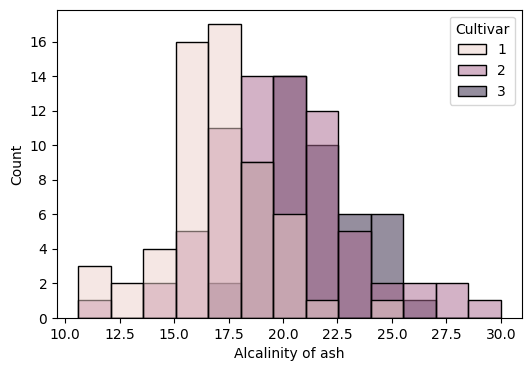

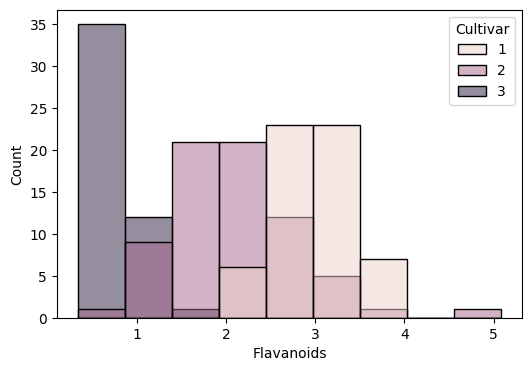

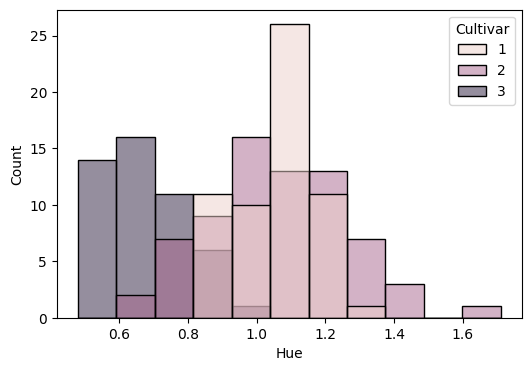

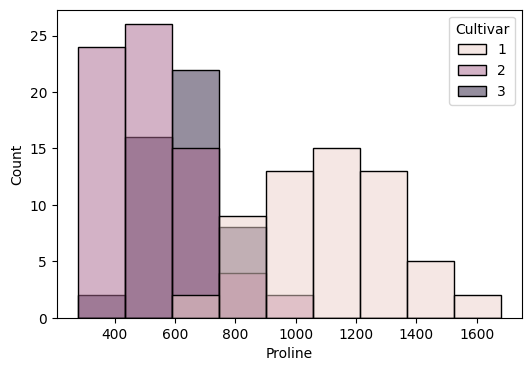

In [75]:
# 3. Distribution plots for 4 features
features = ['Alcalinity of ash', 'Flavanoids', 'Hue', 'Proline']

for f in features:
    plt.figure(figsize = (6, 4))
    sns.histplot(wine_df, x = f, hue = 'Cultivar')
    plt.show()

4. Extract 4 new features (feature-extraction) from the dataset using PCA.<br>a. Print out the amount of variance captured for each Principal Component.<br>b. Print out the total amount of variance captured for the 4 Principal Components.<br>c. Print out the minimum number of Principal Components required to capture at
least 85% of the information of the dataset.<br>d. State the maximum number of Principal Components that can be generated from our dataset?

In [79]:
# 4. PCA feature extraction

# First standardise dataset
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled[:5])

# Print zero-mean and unit-variance to validate
print(f"Mean:\n{np.mean(X_scaled, axis = 0).round()}")
print(f"\nVariance:\n{np.var(X_scaled, axis = 0)}")

# Apply PCA with no. of components = 4
pca = PCA(n_components = 4)
new_features = pca.fit_transform(X_scaled)

# a. Print out amt of variance for each PC
ext_variance = pca.explained_variance_ratio_
print(f"\nAmount of variance per PC [4]:\n{ext_variance}")

# b. Print out total amt of variance for all 4 PCs
print(f"\nTotal amount of variance [4]:\n{ext_variance.sum()}")

# c. Print out min num of PCs required to capture at least 85% of data
pca1 = PCA()
all_new_features = pca1.fit_transform(X_scaled)
all_variance = pca1.explained_variance_ratio_
print(f"\nAmount of variance per PC [ALL]:\n{all_variance}")

# Get list of cumulative variance totals
cum_variance = all_variance.cumsum()
print(f"\nList of cum variance [ALL]:\n{cum_variance}")

# Boolean filter to find index of first total variance to hit .85 (index + 1 = no. of PCs)
mask = cum_variance >= .85
idx = np.argmax(mask)
print(f"\nNo. of minimum PCs:\n{idx + 1}")

# d. State max no. of PCs that can be generated
print(f"\nMax no. of PCs:\n{all_variance.size}")

[[ 1.51861254 -0.5622498   0.23205254 -1.16959318  1.91390522  0.80899739
   1.03481896 -0.65956311  1.22488398  0.25171685  0.36217728  1.84791957
   1.01300893]
 [ 0.24628963 -0.49941338 -0.82799632 -2.49084714  0.01814502  0.56864766
   0.73362894 -0.82071924 -0.54472099 -0.29332133  0.40605066  1.1134493
   0.96524152]
 [ 0.19687903  0.02123125  1.10933436 -0.2687382   0.08835836  0.80899739
   1.21553297 -0.49840699  2.13596773  0.26901965  0.31830389  0.78858745
   1.39514818]
 [ 1.69154964 -0.34681064  0.4879264  -0.80925118  0.93091845  2.49144552
   1.46652465 -0.98187536  1.03215473  1.18606801 -0.42754369  1.18407144
   2.33457383]
 [ 0.29570023  0.22769377  1.84040254  0.45194578  1.28198515  0.80899739
   0.66335127  0.22679555  0.40140444 -0.31927553  0.36217728  0.44960118
  -0.03787401]]
Mean:
[-0. -0. -0. -0. -0.  0. -0.  0. -0.  0.  0.  0. -0.]

Variance:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Amount of variance per PC [4]:
[0.36198848 0.1920749  0.11123631 0.07069